<a href="https://colab.research.google.com/github/omsoni/computer-vision/blob/googlecolab-init/HelmNet_CV_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install -U pip

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q --timeout 1000

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                          # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Input, Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Lambda
from tensorflow.keras.applications.vgg16 import preprocess_input
                                              # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix
from tensorflow.keras import backend
from tensorflow.keras.models import load_model
import pickle

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images
from sklearn.metrics import classification_report

In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


### Controlling Randomness

We need to controls randomness from Python’s built-in random module, inside TensorFlow and Keras, and control non-deterministic behavior in GPUs. This randomness can effects weight initialization, data shuffling and augmentation pipelines and within CNN it can effect the convolution kernels, reduction operations, backpropagation steps causing each training run to produce different results.

In [ ]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image_file_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision/HelmNet/images.npy'
label_file_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision/HelmNet/labels.csv'
model_save_dir = '/content/drive/MyDrive/Colab Notebooks/Computer Vision/HelmNet/saved-models/'

In [ ]:
import numpy as np
# Load the image file of the dataset
rgb_images = np.load(image_file_path)

# Load the labels file of the dataset
labels = pd.read_csv(label_file_path)

# **Exploratory Data Analysis**

In [ ]:
def plot_images(images,labels, rows, cols):
    keys=dict(labels['label'])
    fig = plt.figure(figsize=(10, 8))
    for i in range(cols):
        for j in range(rows):
            random_index = np.random.randint(0, len(labels))
            ax = fig.add_subplot(rows, cols, i * rows + j + 1)
            ax.imshow(images[random_index, :])
            ax.set_title(keys[random_index])
    plt.show()

def grid_plot(img1,img2,gray=False):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))
    axes[0].imshow(img1)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    if gray:
      axes[1].imshow(img2,cmap='gray')
    else:
      axes[1].imshow(img2)
    axes[1].set_title('Processed Image')
    axes[1].axis('off')

    plt.show()

### Show 12 random images: Observations

- The dataset consists of colored images, enabling the model to leverage rich visual features such as color and texture for improved learning.
- Image quality varies across the dataset, with a noticeable presence of blurred images that may impact feature extraction and model performance.
- Helmets are generally visible, but reduced clarity in some images could affect accurate detection.
- There is variation in camera angles, including some improperly oriented (e.g., upside-down) images, which may introduce additional complexity during training.
- Lighting conditions appear acceptable overall, with no significant presence of overly dark images.

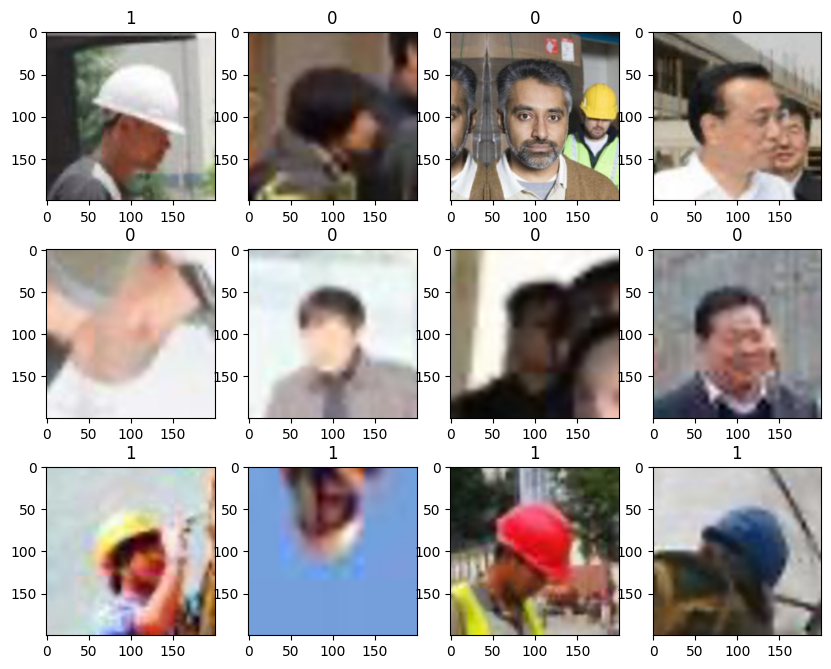

In [ ]:
plot_images(rgb_images,labels,3,4)

In [ ]:
print(rgb_images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


### **Checking for class imbalance**


In [ ]:
labels['label'].value_counts()

,count
label,
1,3161
0,964


There is moderate class imbalance. We will handle that using class weights.

# **Data Preprocessing**

We will test the ANNs, CNNs on three variations of image dataset:

* RGB
* Grayscale
* Grayscale with Laplace Filter

### **Convert images to Grayscale**

Grayscale images:
* Reduces memory usage
* Reduces training time
* Reduces number of parameters

In our use case, grayscale is even more useful:

* It reduces Overfitting as colors can introduce noise
* It forces model to learn structural features instead of irrelevent color patterns which should help in deternmining if workers are wearing the helmet or not.

In [ ]:
gray_images = []
for i in range(len(rgb_images)):
  gray_images.append(cv2.cvtColor(rgb_images[i], cv2.COLOR_RGB2GRAY))
gray_images = np.expand_dims(gray_images, axis=-1)

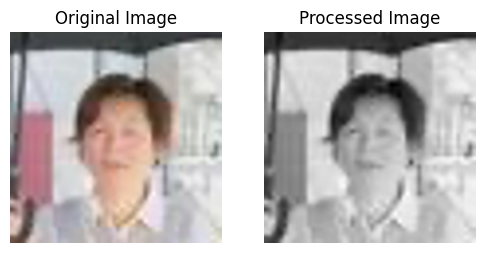

In [ ]:
# choosing an image
n = 50
# plotting the original and preprocessed image
grid_plot(rgb_images[n],gray_images[n],gray=True)

### PreProcessing and Splitting the data into Training, Validation and Test Datasets



### **RGB**

RGB images can provide features such as color of helmet that can help model accurately classify data

- Helmets often have distinct colors (yellow, orange, white)
- Backgrounds (machinery, walls etc) have different color distributions

In [ ]:
# Splitting the dataset into training (80%) and temporary (20%) sets
# stratify=labels ensures that class distribution is maintained in both sets
X_train_rgb_orig, X_temp_rgb, y_train_rgb, y_temp_rgb = train_test_split(np.array(rgb_images),labels , test_size=0.2, random_state=42,stratify=labels)

In [ ]:
# Splitting the temporary set further into validation (50%) and test (50%) sets
# This results in 10% validation and 10% test data from the original dataset
X_val_rgb_orig, X_test_rgb_orig, y_val_rgb, y_test_rgb = train_test_split(X_temp_rgb,y_temp_rgb , test_size=0.5, random_state=42,stratify=y_temp_rgb)

### **Grayscale**

In [ ]:
# Splitting the dataset into training (80%) and temporary (20%) sets
# stratify=labels ensures that class distribution is maintained in both sets
X_train_gray, X_temp_gray, y_train_gray, y_temp_gray = train_test_split(np.array(gray_images),labels , test_size=0.2, random_state=42,stratify=labels)

In [ ]:
# Splitting the temporary set further into validation (50%) and test (50%) sets
# This results in 10% validation and 10% test data from the original dataset
X_val_gray, X_test_gray, y_val_gray, y_test_gray = train_test_split(X_temp_gray,y_temp_gray,test_size=0.5, random_state=42,stratify=y_temp_gray)

## Using Filters for Feature Extraction

#### **Gaussian Blur**

While Gaussian blur is not generally necessary for standard CNN classification, it acts as a powerful augmentation tool to improve model robustness against noise and blurriness. It helps by smoothing images and removing high-frequency noise.

**why it does not make sense for our use case**

* Our images are not high resolution
* Many images are already blurred.

Gaussian blur helps when data is clean and high-res; in this case, it would destroy already limited signal.


#### **Laplacian Filter**

Using a Laplacian filter for grayscale CNN classification can enhance edge detection and improve sharpness, particularly in applications needing to detect fine details, blurred images, or specific, sparse features.

Why use it in our case:

* helps with precise localization of contours
* highlightes edges

both of these can help with accurate prediction.

In [ ]:
edge_images = []
for i in range(len(gray_images)):
    edge_images.append(cv2.Laplacian(gray_images[i],cv2.CV_64F))
edge_images = np.expand_dims(edge_images, axis=-1)

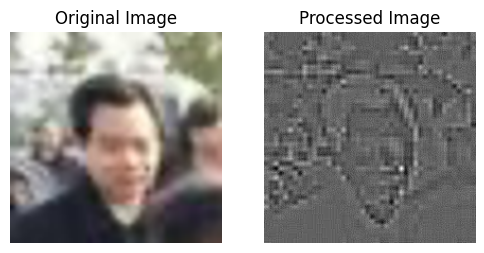

In [ ]:
# choosing an image
n = 10
# plotting the original and preprocessed image
grid_plot(rgb_images[n],edge_images[n],gray=True)

In [ ]:
# Splitting the dataset into training (80%) and temporary (20%) sets
# stratify=labels ensures that class distribution is maintained in both sets
X_train_edge, X_temp_edge, y_train_edge, y_temp_edge = train_test_split(np.array(edge_images),labels , test_size=0.2, random_state=42,stratify=labels)

In [ ]:
# Splitting the temporary set further into validation (50%) and test (50%) sets
# This results in 10% validation and 10% test data from the original dataset
X_val_edge, X_test_edge, y_val_edge, y_test_edge = train_test_split(X_temp_edge,y_temp_edge,test_size=0.5, random_state=42,stratify=y_temp_edge)

### **Data Normalization**

Data normalization helps stabilize training by keeping input values in a consistent range, which improves convergence and numerical stability. It can indirectly reduce issues like exploding or vanishing gradients, especially in deep networks.

#### **Normalize RGB Dataset**

In [ ]:
# Normalizing the image pixels
X_train_rgb = X_train_rgb_orig.astype('float32')/255.0
X_val_rgb = X_val_rgb_orig.astype('float32')/255.0
X_test_rgb = X_test_rgb_orig.astype('float32')/255.0


#### **Normalize Grayscale Dataset**

In [ ]:
# Normalizing the image pixels
X_train_gray = X_train_gray.astype('float32')/255.0
X_val_gray = X_val_gray.astype('float32')/255.0
X_test_gray = X_test_gray.astype('float32')/255.0

#### **Normalize Laplace filtered Dataset**

In [ ]:
# Normalizing the image pixels
X_train_edge = X_train_edge.astype('float32')/255.0
X_val_edge = X_val_edge.astype('float32')/255.0
X_test_edge = X_test_edge.astype('float32')/255.0

# **Model Building**

### **Model Evaluation Criterion**

We have an imbalanced dataset (~70% Class 1, ~30% Class 0)

**Accuracy** depends heavily on class proportions, **AUC** does not.
Considering business importance of detecting positives, best model evaluation  criterion for imbalanced set is **PR-AUC** (Average Precision) as it focuses on minority class performance. AUC is sensitive to false positives & false negatives

* Best single-number summary values for imbalanced datasets is Recall and Precision.
* Recall (Class 0) answers how many true detections do we catch
* Precision (Class 0) tells how how many detection are real

### Utility Functions

In [ ]:
from sklearn.metrics import confusion_matrix

# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>threshold

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    cm = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

    return df_perf, cm

In [ ]:
def plot_history(histories, model_names):
    plt.figure(figsize=(12, 5))

    linestyles = ['-', '--', ':']
    markers = ['o', 's', '^']

    # --- Loss ---
    plt.subplot(1, 2, 1)
    for i, (hist, name) in enumerate(zip(histories, model_names)):
        val_loss = hist.history.get('val_loss')
        if val_loss is None:
            print(f"Skipping {name} (no val_loss)")
            continue

        plt.plot(
            val_loss,
            label=name,
            linestyle=linestyles[i % len(linestyles)],
            marker=markers[i % len(markers)]
        )

    plt.title("Validation Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # --- AUC ---
    plt.subplot(1, 2, 2)
    for i, (hist, name) in enumerate(zip(histories, model_names)):
        val_auc = hist.history.get('val_AUC') or hist.history.get('val_auc')

        if val_auc is None:
            print(f"Skipping {name} (no val_AUC)")
            continue

        plt.plot(
            val_auc,
            label=name,
            linestyle=linestyles[i % len(linestyles)],
            marker=markers[i % len(markers)]
        )

    plt.title("Validation AUC Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
## Dictionary to store all model history
reports = {}

### **Using ImageDataGenerator**

**ImageDataGenerator** is a Keras module used for real-time data augmentation and normalization in deep learning, preventing overfitting by generating augmented images (rotations, flips, zooms etc) during training.

In our use case, Data augmentation can help the model generalize across variations in lighting, orientation, and worker posture commonly encountered in real industrial environments.

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.

- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
## Configure ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

In [ ]:
## Create data generator for RGB
train_generator_rgb = datagen.flow(
    X_train_rgb,
    y_train_rgb,
    batch_size=128
)

In [ ]:
## Create data generator for Grayscale
train_generator_gray = datagen.flow(
    X_train_gray,
    y_train_gray,
    batch_size=128
)

In [ ]:
## Create data generator for Laplace filtered data
train_generator_laplace = datagen.flow(
    X_train_edge,
    y_train_edge,
    batch_size=128
)

### Handling Class imbalance

We can assign proportionate weights to handle class imbalance

In [ ]:
class_weights = {
    0: 3.0,   # without helmet
    1: 1.0    # with helmet
}

### Model 0: Using a ANN as Base Model

## ANN Overview

The ANN is a vanilla fully connected neural network that operates on **flattened image inputs** and is trained using **gradient-based optimization** (e.g., gradient descent) to minimize loss.

Due to the large number of trainable parameters, the model is **computationally inefficient** and prone to overfitting, especially for image data.

### Limitations of ANN for Image Data

- ANN ignores spatial structure in images.
- Images contain important spatial relationships such as edges, textures, and shapes.
- Flattening converts the image into a 1D vector, causing the model to treat pixels as independent features.
- This results in loss of spatial information and reduced ability to capture meaningful visual patterns.

Flatten → Dense(256) → Dense(128) → Dense(64) → Output

For our ANN architecture, we have 400 × 400 × 3 = 480,000 features X 256 neurons = ~ 123 miliion parameters.

In [ ]:
def create_ann_model(shape):
  model = Sequential()
  model.add(Input(shape=shape))
  model.add(Flatten())
  model.add(Dense(256, activation='relu',kernel_initializer='he_uniform'))
  model.add(Dropout(0.5))
  model.add(Dense(128, activation='relu',kernel_initializer='he_uniform'))
  model.add(Dropout(0.2))
  model.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
  model.add(Dense(1, activation='sigmoid'))
  return model

## ANN Architecture

The Artificial Neural Network (ANN) model consists of fully connected (dense) layers applied to flattened image inputs. While this architecture enables nonlinear feature learning, it does not preserve spatial relationships between pixels, which is a limitation for image data compared to CNNs.

### Input Layer
- Input shape: (200, 200, 3)
- Represents RGB images with height and width of 200 pixels.
- No trainable parameters.

### Flatten Layer
- Converts the 3D input (200 × 200 × 3) into a 1D vector.
- Output size: 120,000 neurons
- Parameters: 0

### Fully Connected Layers

#### First Hidden Layer
- Neurons: 256
- Activation: ReLU
- Kernel Initializer: He Uniform
- Dropout: 50%

**Parameters:**
(120000 × 256) + 256 = 30,720,256


#### Second Hidden Layer
- Neurons: 128
- Activation: ReLU
- Kernel Initializer: He Uniform
- Dropout: 20%

**Parameters:**
(256 × 128) + 128 = 32,896

#### Third Hidden Layer
- Neurons: 64
- Activation: ReLU
- Kernel Initializer: He Uniform
- No Dropout

**Parameters:**
(128 × 64) + 64 = 8,256

### Output Layer
- Neurons: 1
- Activation: Sigmoid (for binary classification)

**Parameters:**
(64 × 1) + 1 = 65

### Summary

- Total Parameters: 30,761,473
- The model relies entirely on dense layers, which:
  - Enable nonlinear learning
  - But ignore spatial structure in images
- This results in a large number of parameters and higher risk of overfitting compared to CNN-based architectures.

### **Limitations of ANN**
* No spatial awareness (due to Flatten)
* Cannot detect edges, shapes, or patterns
* Very high number of parameters for images
* Prone to overfitting and class bias

### **Training hyperparameters** implemented as callbacks

We will apply **Early stopping** and **reduced learning rate**

**EarlyStopping** prevents overfitting by halting training when validation AUC no longer improves. ANN memorizes training data quickly (especially with Flatten) Validation performance stops improving while training loss keeps decreasing

**EarlyStopping:**
* Watches validation AUC
* Stops training when performance stops improving.
* Prevents overfitting


**ReduceLROnPlateau** dynamically lowers the learning rate when performance plateaus, allowing the model to converge to a better optimum.

Together, they improve generalization and training efficiency, especially for high-dimensional ANN models prone to instability.

ReduceLROnPlateau:
* If validation AUC stops improving reduce learning rate by 50%
* finer weight updates
* better local optimization
* Stabilizes training
* High LR results in noisy updates
* Lower LR means smoother convergence


In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC',
    mode='max',
    patience=4,
    factor=0.5,
    min_lr=1e-5
)


early_stop = EarlyStopping(
    monitor='val_AUC',
    mode='max',
    patience=10,
    restore_best_weights=True
)

### Determine shape of three datasets we are experimenting with.

In [ ]:
image_size = X_train_rgb[0].size
shape_rgb = X_train_rgb.shape[1:]

In [ ]:
print("RGB image matrix shape:" + str(shape_rgb))
shape_gs = X_train_gray.shape[1:]
print("Grayscale image matrix shape:" + str(shape_gs))
shape_lap = X_train_edge.shape[1:]
print("Grayscale Laplace image matrix shape:" + str(shape_lap))

RGB image matrix shape:(200, 200, 3)
Grayscale image matrix shape:(200, 200, 1)
Grayscale Laplace image matrix shape:(200, 200, 1)


### ANN Model on RGB dataset

In [ ]:
adam = Adam()
model0_ann_rgb = create_ann_model(shape_rgb)
model0_ann_rgb.compile(loss="binary_crossentropy", optimizer=adam, metrics=['AUC'])
model0_ann_rgb.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 120000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    30,720,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,761,473 (117.35 MB)

 Trainable params: 30,761,473 (117.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = model_save_dir + "model0_ann_rgb.keras";
model_history_path = model_save_dir + "history_model0_ann_rgb.pkl";

if os.path.exists(model_path):
  model0_ann_rgb = load_model(model_path)
  if (os.path.exists(model_history_path)):
    with open(model_history_path, "rb") as f:
        history_model0_ann_rgb = pickle.load(f)
else:
  history_model0_ann_rgb = model0_ann_rgb.fit(
      train_generator_rgb,
      validation_data=(X_val_rgb, y_val_rgb),
      epochs=20,
      verbose=2,
      class_weight=class_weights, callbacks=[early_stop, reduce_lr]
  )
  # Save model history
  with open(model_history_path, "wb") as f:
    pickle.dump(history_model0_ann_rgb, f)
  # Save the trained model
  model0_ann_rgb.save(model_path)

104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


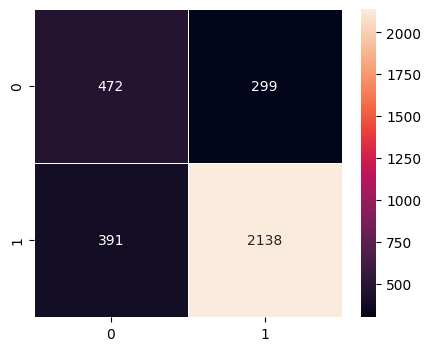

In [ ]:
model0_ann_rgb_train_perf = model_performance_classification(model0_ann_rgb, X_train_rgb,y_train_rgb)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


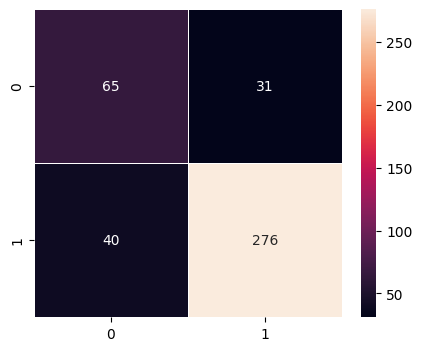

In [ ]:
model0_ann_rgb_valid_perf = model_performance_classification(model0_ann_rgb, X_val_rgb,y_val_rgb)

In [ ]:
y_pred = model0_ann_rgb.predict(X_val_rgb)
classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [ ]:
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
reports['Model0RGB'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score    support
0              0.619048  0.677083  0.646766   96.00000
1              0.899023  0.873418  0.886035  316.00000
accuracy       0.827670  0.827670  0.827670    0.82767
macro avg      0.759035  0.775251  0.766401  412.00000
weighted avg   0.833786  0.827670  0.830283  412.00000


### **Key Observations: ANN Model Performance on RGB Dataset**

The ANN model achieved an overall accuracy of **82.77%**, with a macro F1-score of **0.77** and weighted F1-score of **0.83**.

### Class-wise Performance

- **Class 0 (No Helmet):**
  - Precision: 0.62
  - Recall: 0.68
  - F1-score: 0.65

- **Class 1 (Helmet):**
  - Precision: 0.90
  - Recall: 0.87
  - F1-score: 0.89

### Key Observations

- The model performs significantly better on the majority class (Helmet) compared to the minority class (No Helmet).
- Lower precision and recall for Class 0 indicate difficulty in correctly identifying safety violations.
- The gap between class-wise performance suggests bias toward the majority class due to dataset imbalance.
- Macro F1-score (0.77) is notably lower than weighted F1-score (0.83), highlighting imbalance impact.


### Interpretation

- The ANN struggles to generalize well on image data due to the loss of spatial information caused by flattening.
- High number of parameters increases the risk of overfitting without effectively capturing meaningful visual features.
- As a result, the model underperforms compared to CNN and transfer learning approaches.

### Conclusion

While the ANN provides a reasonable baseline, it is not well-suited for image classification tasks like helmet detection. Models that preserve spatial features (e.g., CNNs or transfer learning models) are more effective for this problem.

### ANN Model on Grayscale dataset

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
adam = Adam()
model0_ann_gs = create_ann_model(shape_gs)
model0_ann_gs.compile(loss="binary_crossentropy", optimizer=adam, metrics=['AUC'])
model0_ann_gs.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,240,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,281,473 (39.22 MB)

 Trainable params: 10,281,473 (39.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = model_save_dir + "model0_ann_gs.keras";
model_history_path = model_save_dir + "model0_ann_gs_history.pkl";
if os.path.exists(model_path):
  model0_ann_rgb = load_model(model_path)
  if (os.path.exists(model_history_path)):
    with open(model_history_path, "rb") as f:
        history_model0_ann_gs = pickle.load(f)
else:
  history_model0_ann_gs = model0_ann_gs.fit(
      train_generator_gray,
      validation_data=(X_val_gray, y_val_gray),
      epochs=20,
      verbose=2,
      class_weight=class_weights, callbacks=[early_stop, reduce_lr]
  )
  # save model and model history
  with open(model_history_path, "wb") as f:
    pickle.dump(history_model0_ann_gs, f)
  model0_ann_gs.save(model_path)


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


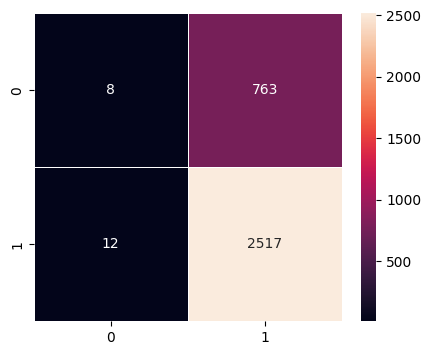

In [ ]:
model0_train_gs_perf, cm = model_performance_classification(model0_ann_gs, X_train_gray,y_train_gray)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


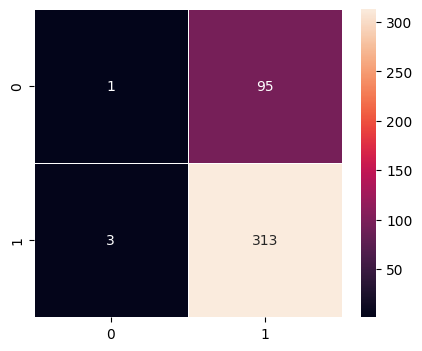

In [ ]:
model0_ann_gs_valid_perf = model_performance_classification(model0_ann_gs, X_val_gray,y_val_gray)

In [ ]:
y_pred = model0_ann_gs.predict(X_val_gray)
classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
report_dict = classification_report(y_val_gray, classes,  output_dict=True)
reports['Model0GS'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.250000  0.010417  0.020000   96.000000
1              0.767157  0.990506  0.864641  316.000000
accuracy       0.762136  0.762136  0.762136    0.762136
macro avg      0.508578  0.500461  0.442320  412.000000
weighted avg   0.646654  0.762136  0.667831  412.000000


### **Observations: ANN with Grayscale**

### ANN (Grayscale) Model Performance

The ANN model trained on grayscale images achieved an overall accuracy of **76.21%**, with a macro F1-score of **0.44** and weighted F1-score of **0.67**.

### Class-wise Performance

- **Class 0 (No Helmet):**
  - Precision: 0.25
  - Recall: 0.01
  - F1-score: 0.02

- **Class 1 (Helmet):**
  - Precision: 0.77
  - Recall: 0.99
  - F1-score: 0.86


### Key Observations

- The model almost completely fails to detect the minority class (No Helmet), with recall close to zero.
- Extremely low recall (0.01) indicates that nearly all “No Helmet” cases are misclassified as “Helmet.”
- High recall for Class 1 (0.99) suggests the model is heavily biased toward predicting the majority class.
- The large gap between macro F1 (0.44) and weighted F1 (0.67) highlights severe class imbalance impact.


### Interpretation

- Converting images to grayscale removes important color information, which is critical for distinguishing helmets from the background.
- The ANN architecture further compounds the issue by flattening inputs, leading to loss of spatial features.
- As a result, the model defaults to predicting the majority class, failing in safety-critical detection.


### Conclusion

The combination of grayscale input and ANN architecture leads to severe performance degradation, particularly for the minority class. This approach is not suitable for this problem, as it fails to reliably detect safety violations.

### ANN Model on Grayscale dataset with Laplace filter

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
adam = Adam()
model0_ann_lap = create_ann_model(shape_gs)
model0_ann_lap.compile(loss="binary_crossentropy", optimizer=adam, metrics=['AUC'])

In [ ]:
model0_ann_lap.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,240,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,281,473 (39.22 MB)

 Trainable params: 10,281,473 (39.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = model_save_dir + "model0_ann_lap.keras";
model_history_path = model_save_dir + "model0_ann_lap_history.pkl";

if os.path.exists(model_path):
  model0_ann_rgb = load_model(model_path)
  if (os.path.exists(model_history_path)):
    with open(model_history_path, "rb") as f:
        history_model0_ann_lap = pickle.load(f)
else:
  history_model0_ann_lap = model0_ann_lap.fit(
      train_generator_laplace,
      validation_data=(X_val_edge, y_val_edge),
      epochs=20,
      verbose=2,
      class_weight=class_weights, callbacks=[early_stop, reduce_lr]
  )
  # Save model and model history
  with open(model_history_path, "wb") as f:
    pickle.dump(history_model0_ann_gs, f)
  model0_ann_lap.save(model_path)

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


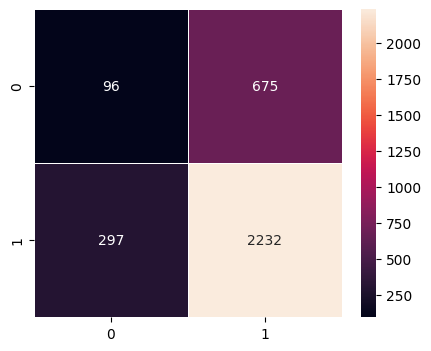

In [ ]:
model0_ann_lap_train_perf, cm = model_performance_classification(model0_ann_lap, X_train_edge,y_train_edge)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


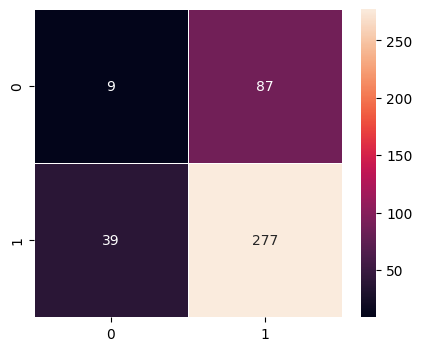

In [ ]:
model0_ann_lap_valid_perf, cm = model_performance_classification(model0_ann_lap, X_val_edge,y_val_edge)

In [ ]:
y_pred = model0_ann_lap.predict(X_val_edge)
classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
report_dict = classification_report(y_val_edge, classes,  output_dict=True)
reports['Model0LAP'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.187500  0.093750  0.125000   96.000000
1              0.760989  0.876582  0.814706  316.000000
accuracy       0.694175  0.694175  0.694175    0.694175
macro avg      0.474245  0.485166  0.469853  412.000000
weighted avg   0.627361  0.694175  0.653998  412.000000


### Observations: ANN with Laplacian edge

#### **Model Performance**

The ANN model trained on Laplacian-filtered (edge-detected) images achieved an overall accuracy of **69.42%**, with a macro F1-score of **0.47** and weighted F1-score of **0.65**.

### Class-wise Performance

- **Class 0 (No Helmet):**
  - Precision: 0.19
  - Recall: 0.09
  - F1-score: 0.13

- **Class 1 (Helmet):**
  - Precision: 0.76
  - Recall: 0.88
  - F1-score: 0.81

### Key Observations

- The model performs poorly on the minority class (No Helmet), with very low recall (0.09).
- A significant number of safety violations are misclassified as “Helmet.”
- Performance is slightly better than grayscale for Class 0 recall, but still inadequate.
- Overall accuracy (69%) is the lowest among all ANN variants tested.
- Macro F1-score remains low (0.47), indicating poor balanced performance.

### Interpretation

- The Laplacian filter retains only edge information while removing color and texture.
- Helmet detection requires richer features such as color, texture, and contextual information, which are lost after edge extraction.
- The ANN model, already limited by lack of spatial awareness, is further constrained by reduced input information.
- As a result, the model struggles to distinguish meaningful patterns and defaults toward majority class predictions.

### Conclusion

Using Laplacian-filtered images significantly degrades ANN performance. Edge-only representations are insufficient for this task, confirming that preserving full visual information (color and texture) is essential for accurate helmet detection.


### Observaltions: Performance Comparison

Overall Class-wise Performance Comparison for **all ANN models**

#### Class 0 — No Helmet (Minority Class)

| Metric     | Model0RGB | Model0GS | Model0LAP |
|-----------|----------|----------|----------|
| Precision | 0.6190   | 0.2500   | 0.1875   |
| Recall    | 0.6771  | 0.0104  | 0.0938 |
| F1-score  | 0.6468 | 0.0200 | 0.1250 |

---

#### Class 1 — Helmet (Majority Class)

| Metric     | Model0RGB | Model0GS | Model0LAP |
|-----------|----------|----------|----------|
| Precision | 0.8990   | 0.7672   | 0.7610   |
| Recall    | 0.8734   | 0.9905 | 0.8766   |
| F1-score  | 0.8860 | 0.8646   | 0.8147   |

### Overall Performance Comparison

| Metric         | Model0RGB | Model0GS | Model0LAP |
|---------------|-------------|------------|-------------|
| Accuracy      | 0.8277      | 0.7621     | 0.6942      |
| Macro Avg Precision | 0.7590 | 0.5086     | 0.4742      |
| Macro Avg Recall    | 0.7753 | 0.5005     | 0.4852      |
| Macro Avg F1-score  | 0.7664  | 0.4423 | 0.4699 |
| Weighted Precision  | 0.8338 | 0.6467     | 0.6274      |
| Weighted Recall     | 0.8277 | 0.7621     | 0.6942      |
| Weighted F1-score   | 0.8303 | 0.6678    | 0.6540      |

### **Summary:**
- Model0RGB achieves the best overall and balanced performance.
- Model0GS shows misleading accuracy due to poor minority class detection.
- Model0LAP performs weakest overall, indicating loss of important features.

In [ ]:
ann_histories = [history_model0_ann_rgb, history_model0_ann_gs, history_model0_ann_lap]
model_names = ["Model0RGB", "Model0GS", "Model0LAP"]

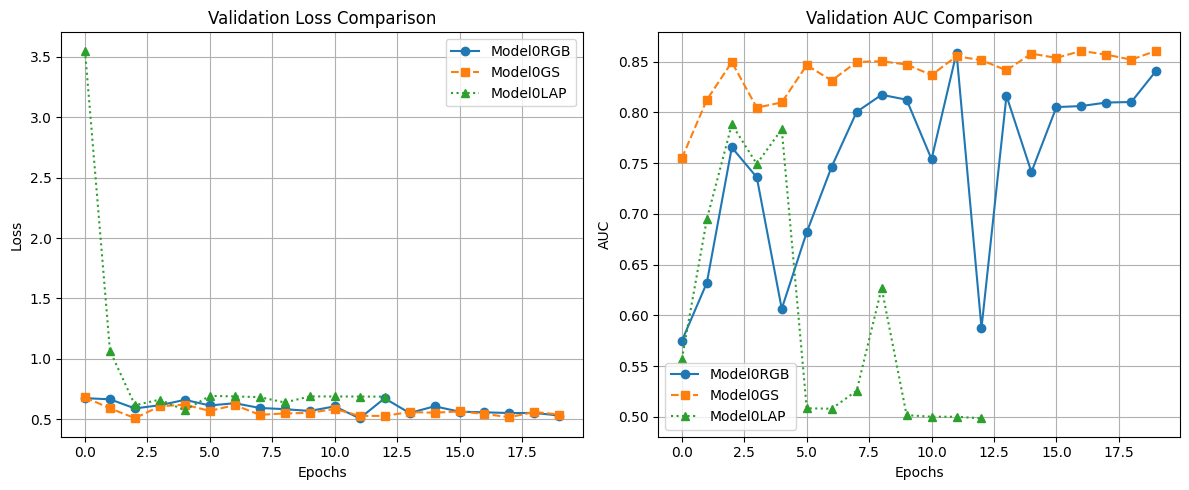

In [ ]:
plot_history(ann_histories, model_names)

## Observations from Model Training history

The grayscale model achieved the highest and most stable AUC (~0.85), indicating better class separability and generalization. The RGB model showed improving but unstable performance, suggesting difficulty in handling high-dimensional input. The Laplacian model performed poorly, with AUC dropping to ~0.5, indicating loss of critical information. Overall, grayscale input provided the best trade-off between simplicity and performance for ANN.

**Model0GS** (Grayscale) is the most stable model
Highest AUC (~0.85 - 0.86), Smooth learning curve, Consistent convergence

* Good class separation
* Learns meaningful patterns
* Generalizes well

**Model0RGB** is unstable improves over time (~0.57 to ~0.84)
But has big drops (e.g., around epoch 12)

* Learning is inconsistent
* Likely overfitting or noisy gradients
* Model struggles with RGB complexity

Model0LAP looks shows poor learning, shows huge initial loss (~ 3.5)
then drops but plateaus high (~ 0.65 - 0.7)

* Model initially confused
* Never really learns meaningful representation


### **Weighted Average from Classification Report ***

In [ ]:
df_list = []
for name, report in reports.items():
    df = pd.DataFrame(report).transpose()
    df["model"] = name
    df_list.append(df)

df_all = pd.concat(df_list).reset_index().rename(columns={"index": "class"})

summary = df_all[df_all["class"] == "weighted avg"][
    ["model", "precision", "recall", "f1-score"]
].sort_values("f1-score", ascending=False)

summary

,model,precision,recall,f1-score
4,Model0RGB,0.833786,0.827670,0.830283
9,Model0GS,0.646654,0.762136,0.667831
14,Model0LAP,0.627361,0.694175,0.653998


** Class 0 performance comparision **

| Metric   | RGB (Model0RGB) | Grayscale (Model0GS) | Laplacian (Model0Lap) |
|----------|-----------------|----------------------|------------------------|
| Precision| 0.619           | 0.250                | 0.188                  |
| Recall   | 0.677           | 0.010 *         | 0.094 *             |
| F1-Score | 0.647 *       | 0.020 *           | 0.125 *               |
| Support  | 96              | 96                   | 96                     |

** Class 1 performance comparision **

| Metric   | RGB (Model0RGB) | Grayscale (Model0GS) | Laplacian (Model0Lap) |
|----------|-----------------|----------------------|------------------------|
| Precision| 0.899           | 0.767                | 0.761                  |
| Recall   | 0.873           | 0.991 *    | 0.877                  |
| F1-Score | 0.886 *   | 0.865                | 0.815                  |
| Support  | 316             | 316                  | 316                    |

**Interpretation:**

- RGB model provides the most balanced performance across both classes.
- Grayscale model severely underperforms on Class 0 (No Helmet), with near-zero recall.
- Laplacian model performs slightly better than grayscale for Class 0 but remains weak overall.
- All models perform relatively well on Class 1 (Helmet), indicating class imbalance bias.

## Model 1: Using Convolutional Neural Network (CNN) from Scratch

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
def create_cnn_model(shape):
    model = Sequential()

    model.add(Input(shape=shape))

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    # Classifier
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu', kernel_initializer='he_uniform'))

    model.add(Dense(1, activation='sigmoid'))

    return model

The CNN architecture consists of three convolutional blocks with increasing filter sizes (32, 64, 128) to hierarchically extract features from images, followed by fully connected layers for classification. Convolution and pooling layers capture spatial patterns such as edges, shapes, and object-level features, making CNNs significantly more effective than ANNs for image classification tasks.

Convulution Layer:

**Block 1**

* 32 filters (3×3) scan the image to learns low-level features suedges
corners textures
* MaxPooling (2×2) reduces spatial size by half and keeps strongest features

**Block 2**

* 64 filters to learns mid-level features such as shapes and object parts
* More filters = richer representation

**Block 3**

* 128 filters to learns high-level features:
* object-level patterns (e.g., helmet shape)
* Strong abstraction of image content

**Classification Head (FFNN)**

It has two Dense Layers and an Output Layer.

We will try SGD and then shift to Adam for faster convergence.


### **CNN with RGB**

In [ ]:
model1_cnn_rgb = create_cnn_model(shape_rgb)

opt = SGD(learning_rate=0.01, momentum=0.9)

model1_cnn_rgb.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy','AUC']
)
model1_cnn_rgb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,590,017 (78.54 MB)

 Trainable params: 20,590,017 (78.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = model_save_dir + "model1_cnn_rgb.keras";
model_history_path = model_save_dir + "model1_cnn_rgb_history.pkl";

if os.path.exists(model_path):
  model1_cnn_rgb = load_model(model_path)
  if (os.path.exists(model_history_path)):
    with open(model_history_path, "rb") as f:
        history_model1_cnn_rgb = pickle.load(f)
else:
  history_model1_cnn_rgb = model1_cnn_rgb.fit(
      train_generator_rgb,
      validation_data=(X_val_rgb, y_val_rgb),
      epochs=20,
      verbose=2,
      class_weight=class_weights, callbacks=[early_stop, reduce_lr]
  )
  with open(model_history_path, "wb") as f:
    pickle.dump(history_model1_cnn_rgb, f)
  model1_cnn_rgb.save(model_path)

In [ ]:
y_pred = model1_cnn_rgb.predict(X_val_rgb)
classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [ ]:
cnn_reports = {}
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
cnn_reports['Model1RGB'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.700000  0.947917  0.805310   96.000000
1              0.982270  0.876582  0.926421  316.000000
accuracy       0.893204  0.893204  0.893204    0.893204
macro avg      0.841135  0.912249  0.865866  412.000000
weighted avg   0.916498  0.893204  0.898201  412.000000


104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step


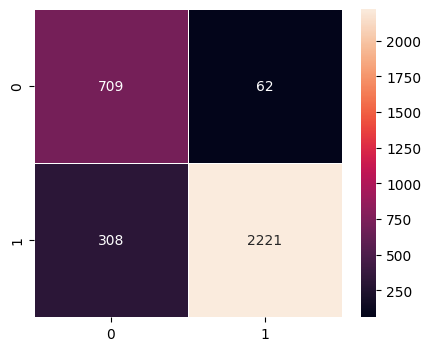

In [ ]:
model1_train_rgb_perf, cm = model_performance_classification(model1_cnn_rgb, X_train_rgb,y_train_rgb)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


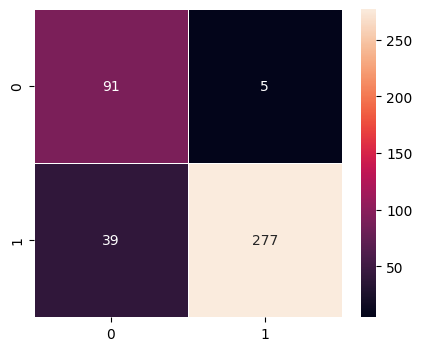

In [ ]:
model1_val_rgb_perf, cm = model_performance_classification(model1_cnn_rgb, X_val_rgb,y_val_rgb)

### **Key Observations: CNN with RGB**

- The model achieves very high recall (0.95) for Class 0, indicating strong ability to detect safety violations.
- Precision for Class 0 (0.70) is lower, suggesting some false positives (over-detection of violations).
- High precision for Class 1 (0.98) indicates reliable identification of compliant cases.
- Macro F1-score (0.87) reflects balanced performance across both classes.
- Overall accuracy (89.32%) is significantly higher than ANN-based models.


### Interpretation

- The CNN effectively captures spatial features such as edges, textures, and shapes, which are critical for image classification tasks.
- Using RGB input preserves color information, further improving the model’s ability to distinguish helmets from the background.
- High recall for Class 0 is particularly valuable in this safety-critical application, as it minimizes missed violations.

### Conclusion

The CNN model with RGB input demonstrates strong performance and a good balance between precision and recall. It significantly outperforms ANN-based approaches and is well-suited for detecting safety violations in real-world scenarios.

## CNN with Grayscale

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
model1_cnn_gs = create_cnn_model(shape_gs)

opt = Adam(learning_rate=0.0001)

model1_cnn_gs.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy','AUC']
)
model1_cnn_gs.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,589,441 (78.54 MB)

 Trainable params: 20,589,441 (78.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = model_save_dir + "model1_cnn_gs.keras";
model_history_path = model_save_dir + "model1_cnn_gs_history.pkl";

if os.path.exists(model_path):
  model1_cnn_gs = load_model(model_path)
  if (os.path.exists(model_history_path)):
    with open(model_history_path, "rb") as f:
        history_model1_cnn_gs = pickle.load(f)
else:
  history_model1_cnn_gs = model1_cnn_gs.fit(
    train_generator_gray,
    validation_data=(X_val_gray, y_val_gray),
    epochs=20,
    verbose=2,
    class_weight=class_weights, callbacks=[early_stop, reduce_lr]
)

  with open(model_history_path, "wb") as f:
    pickle.dump(history_model1_cnn_gs, f)
  model1_cnn_gs.save(model_path)

In [ ]:
y_pred = model1_cnn_gs.predict(X_val_gray)
classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:
report_dict = classification_report(y_val_gray, classes,  output_dict=True)
cnn_reports['Model1GS'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.535948  0.854167  0.658635   96.000000
1              0.945946  0.775316  0.852174  316.000000
accuracy       0.793689  0.793689  0.793689    0.793689
macro avg      0.740947  0.814742  0.755404  412.000000
weighted avg   0.850412  0.793689  0.807077  412.000000


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


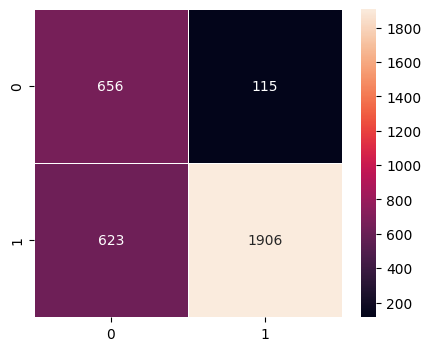

In [ ]:
model1_train_gs_perf, cm = model_performance_classification(model1_cnn_gs, X_train_gray,y_train_gray)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


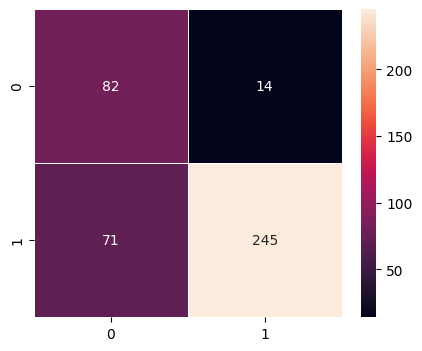

In [ ]:
model1_val_gs_perf, cm = model_performance_classification(model1_cnn_gs, X_val_gray,y_val_gray)

### **Key Observations: CNN with Grayscale**

- The model achieves good recall (0.85) for Class 0, indicating reasonable detection of safety violations.
- Precision for Class 0 (0.54) is relatively low, leading to higher false positives.
- Class 1 precision remains high (0.95), but recall drops compared to the RGB model.
- Overall accuracy (79.37%) is significantly lower than CNN with RGB input (~89%).
- Macro F1-score (0.76) indicates moderate but not optimal balance across classes.

### Interpretation

- The CNN architecture successfully captures spatial features even with grayscale input, resulting in better performance than ANN-based models.
- However, converting images to grayscale removes important color information, which limits the model’s ability to distinguish helmets from the background.
- This results in reduced overall accuracy and weaker class balance compared to RGB-based CNN.

### Conclusion

While CNN with grayscale input performs better than ANN models, it underperforms compared to CNN with RGB images. This confirms that both spatial features and color information are important for accurate helmet detection.

## CNN with Laplace Filter

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
model1_cnn_lap = create_cnn_model(shape_gs)

opt = Adam(learning_rate=0.0001)

model1_cnn_lap.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy','AUC']
)
model1_cnn_lap.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,589,441 (78.54 MB)

 Trainable params: 20,589,441 (78.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = model_save_dir + "model1_cnn_lap.keras";
model_history_path = model_save_dir + "model1_cnn_lap_history.pkl";
if os.path.exists(model_path):
  model1_cnn_lap = load_model(model_path)
  if (os.path.exists(model_history_path)):
    with open(model_history_path, "rb") as f:
        history_model1_cnn_lap = pickle.load(f)
else:
  history_model1_cnn_lap = model1_cnn_lap.fit(
      train_generator_laplace,
      validation_data=(X_val_edge, y_val_edge),
      epochs=20,
      verbose=2,
      class_weight=class_weights, callbacks=[early_stop, reduce_lr]
  )

  with open(model_history_path, "wb") as f:
    pickle.dump(history_model1_cnn_lap, f)
  model1_cnn_lap.save(model_path)

In [ ]:
y_pred = model1_cnn_lap.predict(X_val_edge)
classes = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
report_dict = classification_report(y_val_edge, classes,  output_dict=True)
cnn_reports['Model1Lap'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.333333  0.197917  0.248366   96.000000
1              0.783099  0.879747  0.828614  316.000000
accuracy       0.720874  0.720874  0.720874    0.720874
macro avg      0.558216  0.538832  0.538490  412.000000
weighted avg   0.678299  0.720874  0.693411  412.000000


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


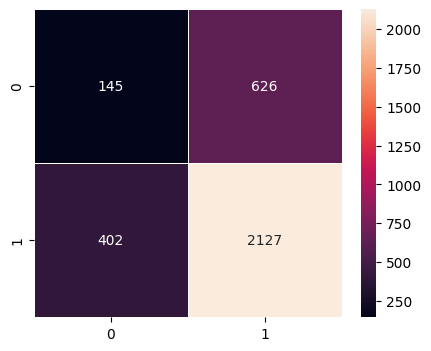

In [ ]:
model1_train_lap_perf, cm = model_performance_classification(model1_cnn_lap, X_train_edge,y_train_edge)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


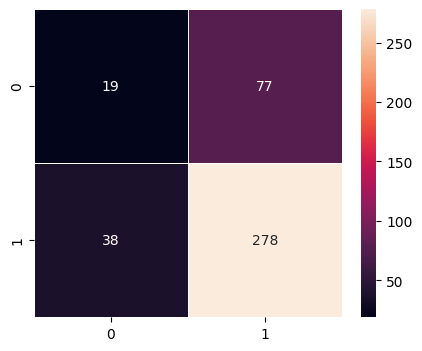

In [ ]:
model1_val_lap_perf, cm = model_performance_classification(model1_cnn_lap, X_val_edge,y_val_edge)

### **Key Observations: CNN with Laplace**

- Class 0 performance is very poor:
  - Recall (0.20) indicates most violations are missed.
  - Precision (0.33) shows high false positives as well.
- Class 1 performs reasonably well, but this is misleading due to class imbalance.
- Overall accuracy (72.09%) is significantly lower than both RGB and grayscale CNN models.
- Macro F1-score (0.54) indicates poor balance between classes.

### Interpretation

- The Laplacian filter extracts only edge information, removing color and texture details.
- While edges are useful, they are insufficient for distinguishing helmets from complex backgrounds.
- Critical visual cues such as color contrast and surface texture are lost.
- This severely impacts the model’s ability to detect Class 0 (No Helmet).

### Conclusion

The CNN model trained on Laplacian-filtered images performs poorly compared to RGB and grayscale inputs. This demonstrates that edge-only representations are not adequate for this classification task, and richer feature information (color + texture) is essential for accurate performance.


### **Observations on CNN Models**

The CNN-based models significantly outperform the ANN models, particularly in detecting the minority class (no helmet).

The **RGB CNN model** achieves the best overall performance with an accuracy of 89% and a macro F1-score of 0.86, indicating strong balanced classification.

Unlike ANN, the CNN model is able to effectively learn spatial features, resulting in a substantial improvement in minority class recall (0.95).

While the **Grayscale CNN model** performs reasonably well, the **Laplacian model** continues to underperform, suggesting that edge-only representations are insufficient for accurate classification.

### Overall Performance Comparison (CNN Models)

| Metric              | Model1RGB| Model1GS | Model1Lap |
|--------------------|-------------|------------|-------------|
| Accuracy           | 0.8932      | 0.7937     | 0.7209      |
| Macro Avg Precision| 0.8411      | 0.7409     | 0.5582      |
| Macro Avg Recall   | 0.9122      | 0.8147     | 0.5388      |
| Macro Avg F1-score | 0.8659 | 0.7554     | 0.5385      |
| Weighted Precision | 0.9165      | 0.8504     | 0.6783      |
| Weighted Recall    | 0.8932      | 0.7937     | 0.7209      |
| Weighted F1-score  | 0.8982  | 0.8071     | 0.6934      |


### Class-wise Performance Comparison (CNN Models)

#### Class 0 — No Helmet (Minority Class)

| Metric     | Model1RGB | Model1GS | Model1Lap |
|-----------|-------------|------------|-------------|
| Precision | 0.7000      | 0.5359     | 0.3333      |
| Recall    | 0.9479   | 0.8542     | 0.1979   |
| F1-score  | 0.8053   | 0.6586     | 0.2484   |

---

#### Class 1 — Helmet (Majority Class)

| Metric     | Model1RGB | Model1GS | Model1Lap |
|-----------|-------------|------------|----------|
| Precision | 0.9823      | 0.9459     | 0.7831   |
| Recall    | 0.8766      | 0.7753     | 0.8797   |
| F1-score  | 0.9264 | 0.8522     | 0.8286   |

In [ ]:
cnn_histories = [history_model1_cnn_rgb, history_model1_cnn_gs, history_model1_cnn_lap]
model_names = ["Model1RGB", "Model1GS", "Model1Lap"]

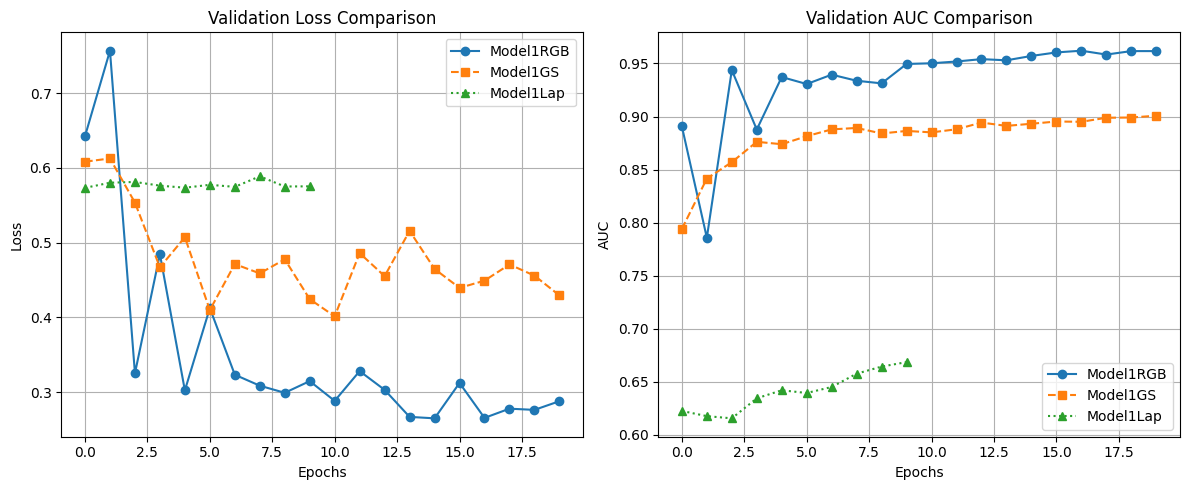

In [ ]:
plot_history(cnn_histories, model_names)

### **Observations from CNN model history plots**

The validation loss and AUC curves clearly show that the **RGB-based CNN model** achieves the best performance, with the lowest validation loss (~ 0.27) and highest AUC (~ 0.96), indicating strong learning and generalization.

The **grayscale model** shows moderate performance, with higher loss and lower AUC (~0.90), suggesting some loss of discriminative information.

The **Laplacian model** performs poorly, with nearly constant validation loss and low AUC (~0.65), indicating underfitting due to excessive loss of image information.

Overall, the results demonstrate that richer input representations significantly improve CNN performance.

**Validation Loss Comparison**
* Model1RGB (blue) shows Sharp drop early fast learning. It stabilizes around   ~0.27–0.30 (lowest). Slight fluctuations are normal, not concerning

* Model1GS (orange) shows gradual decline, slower learning
It stabilizes around ~0.43–0.47 woth noticeable oscillations, showing it is less stable

* Model1Lap (green) is almost flat around ~0.57. It hardly improves → underfitting

**Validation AUC Comparison**
* Model1RGB (blue) shows rapid rise. It reaches ~0.95–0.96 attains stable plateau and shows strong generalization
* Model1GS (orange) shows smooth increase reaches ~0.89–0.90. IT is consistent but lower ceiling
* Model1Lap (green) shows very low AUC ~0.62–0.67

## Model 2: Transfer Learning with VGG-16 (Base)

Uses VGG-16 pretrained on ImageNet as-is
Only adds a minimal output layer
Fastest to train, least flexible
Works well if your data is similar to ImageNet

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

A pretrained VGG16 model was used with a minimal classification head. Input images were resized and preprocessed using the same transformation applied during ImageNet training to ensure compatibility with pretrained weights.

In [ ]:
from tensorflow.keras.applications import VGG16

# Load pretrained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### **Flatten vs GlobalAveragePooling2D**

Flatten creates large parameter-heavy representations, while GlobalAveragePooling2D provides a compact, generalizable feature summary, making it better suited for modern CNN architectures. I have first tried Flatten and then changed to GlobalAveragePooling2D.

In [ ]:
## GlobalAveragePooling2D reduces the spatial dimensions (height and width) of 4D input tensors (usually batch, height, width, channels)
## to a 2D tensor by computing the average value of each feature map
vgg_base_model = tf.keras.Sequential([
    Resizing(224, 224),
    Lambda(preprocess_input),
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

In [ ]:
vgg_base_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['AUC','accuracy'])
vgg_base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
## Fitting the VGG model
vgg_base_model_history = vgg_base_model.fit(X_train_rgb_orig, y_train_rgb,
                                  validation_data=(X_val_rgb_orig, y_val_rgb),
                                  shuffle=True,
                                  batch_size=64,
                                  epochs=20,
                                  verbose=2,
                                  class_weight=class_weights,
                                  callbacks=[early_stop, reduce_lr])

Epoch 1/20
52/52 - 25s - 480ms/step - AUC: 0.4995 - accuracy: 0.6767 - loss: 2.5568 - val_AUC: 0.5178 - val_accuracy: 0.6262 - val_loss: 1.0609 - learning_rate: 1.0000e-04
Epoch 2/20
52/52 - 16s - 308ms/step - AUC: 0.5173 - accuracy: 0.5900 - loss: 1.9249 - val_AUC: 0.5726 - val_accuracy: 0.6141 - val_loss: 1.0161 - learning_rate: 1.0000e-04
Epoch 3/20
52/52 - 17s - 327ms/step - AUC: 0.5849 - accuracy: 0.6158 - loss: 1.6130 - val_AUC: 0.6469 - val_accuracy: 0.6408 - val_loss: 0.8733 - learning_rate: 1.0000e-04
Epoch 4/20
52/52 - 17s - 336ms/step - AUC: 0.6523 - accuracy: 0.6527 - loss: 1.3694 - val_AUC: 0.7105 - val_accuracy: 0.6723 - val_loss: 0.7573 - learning_rate: 1.0000e-04
Epoch 5/20
52/52 - 17s - 319ms/step - AUC: 0.7115 - accuracy: 0.6885 - loss: 1.1783 - val_AUC: 0.7624 - val_accuracy: 0.7087 - val_loss: 0.6684 - learning_rate: 1.0000e-04
Epoch 6/20
52/52 - 16s - 314ms/step - AUC: 0.7601 - accuracy: 0.7209 - loss: 1.0298 - val_AUC: 0.8016 - val_accuracy: 0.7306 - val_loss: 0.6

In [ ]:
y_pred = vgg_base_model.predict(X_val_rgb_orig)
classes = (y_pred > 0.35).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step


In [ ]:
print(np.unique(classes))
print(np.bincount(classes.flatten()))


[0 1]
[106 306]


In [ ]:
vgg_reports = {}
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
vgg_reports['Model2VGG'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.707547  0.781250  0.742574   96.000000
1              0.931373  0.901899  0.916399  316.000000
accuracy       0.873786  0.873786  0.873786    0.873786
macro avg      0.819460  0.841574  0.829486  412.000000
weighted avg   0.879219  0.873786  0.875896  412.000000


## Observations: VGG16 Base Model

The model shows significant improvements after many attemps. Initially VGG16 failed to learn, with predictions collapsing to a constant output. After investigation, I identified a preprocessing mismatch—combining manual normalization with ImageNet preprocessing. Once corrected, the model immediately began learning and achieved ~0.95 AUC with strong generalization.

This shows the importance of aligning data pipelines with pretrained model expectations.


**Confusion metrics** shows
- Class 0 (No helmet) precision: of 0.70 that means the “no helmet”, predictions are wrong ~30% of the time
- Recall: 0.85 - model catches most violations
- Good recall, weaker precision

Class 1 ( “Helmet” — majority class)
- Precision: 0.95 - model is very reliable
- Recall: 0.87 - model shows strong recall
- Model is very confident on the majority class


In [ ]:
import numpy as np

# Define ranges
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

hist, edges = np.histogram(y_pred, bins=bins)

for i in range(len(hist)):
    print(f"{edges[i]:.1f}–{edges[i+1]:.1f}: {hist[i]}")

0.0–0.2: 82
0.2–0.4: 28
0.4–0.6: 26
0.6–0.8: 38
0.8–1.0: 238


The model is not confidently predicting class 1 (like 0.95+).
Instead, it is producing a nearly constant probability for every input image
This tells that model learned a constant function. VGG16 is frozen → no feature adaptation
Final layer is too simple and unable to separate classes. So optimizer finds easiest solutionSeems like model is learning P(class=1) ≈ 0.76 → outputs ~0.7 for everything based on Class 1 proportion in training dataset (which is 76%)

The model converged to a constant output approximating the class prior (~0.7), indicating that the frozen feature extractor combined with a weak classifier head failed to learn discriminative features. This is a representation learning failure rather than a thresholding issue.

## Model 3: Transfer Learning with VGG16 (Base + FFNN)

Adds fully connected (dense) layers on top of frozen VGG-16
The FFNN learns to interpret VGG-16's features for your specific problem
More flexible than Base alone
Better when your data somewhat differs from ImageNet




In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
## GlobalAveragePooling2D reduces the spatial dimensions (height and width) of 4D input tensors (usually batch, height, width, channels)
## to a 2D tensor by computing the average value of each feature map
vgg_ffnn_model = tf.keras.Sequential([
    Resizing(224, 224),
    Lambda(preprocess_input),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

### **Fine Tuning Learning Rate**
Although **ReduceLROnPlateau** and **EarlyStopping** were correctly configured to monitor validation AUC, the lack of significant AUC improvement caused premature learning rate decay and early stopping. Introducing a **minimum delta** helps avoid reacting to noise, while proper fine-tuning with a lower learning rate is essential for meaningful convergence.

In [ ]:
reduce_lr_vgg = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC',
    mode='max',
    patience=3,
    factor=0.5,
    min_lr=1e-5,
    min_delta=0.01   # important
)

early_stop_vgg = EarlyStopping(
    monitor='val_AUC',
    mode='max',
    patience=6,
    min_delta=0.01,   # important
    restore_best_weights=True
)

In [ ]:
vgg_ffnn_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['AUC','accuracy'])
vgg_ffnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
## Fitting the VGG model with FFNN

## Fitting the VGG model
vgg_ffnn_model_history = vgg_ffnn_model.fit(X_train_rgb_orig, y_train_rgb,
                                  validation_data=(X_val_rgb_orig, y_val_rgb),
                                  shuffle=True,
                                  batch_size=64,
                                  epochs=20,
                                  verbose=2,
                                  class_weight=class_weights,
                                  callbacks=[early_stop_vgg, reduce_lr_vgg])

Epoch 1/20
52/52 - 22s - 428ms/step - AUC: 0.7314 - accuracy: 0.6979 - loss: 1.2013 - val_AUC: 0.9266 - val_accuracy: 0.7791 - val_loss: 0.4272 - learning_rate: 1.0000e-04
Epoch 2/20
52/52 - 18s - 340ms/step - AUC: 0.8875 - accuracy: 0.8176 - loss: 0.6589 - val_AUC: 0.9504 - val_accuracy: 0.8641 - val_loss: 0.3233 - learning_rate: 1.0000e-04
Epoch 3/20
52/52 - 17s - 324ms/step - AUC: 0.9375 - accuracy: 0.8618 - loss: 0.4736 - val_AUC: 0.9583 - val_accuracy: 0.8859 - val_loss: 0.2875 - learning_rate: 1.0000e-04
Epoch 4/20
52/52 - 16s - 315ms/step - AUC: 0.9419 - accuracy: 0.8745 - loss: 0.4679 - val_AUC: 0.9648 - val_accuracy: 0.9029 - val_loss: 0.2527 - learning_rate: 1.0000e-04
Epoch 5/20
52/52 - 16s - 316ms/step - AUC: 0.9561 - accuracy: 0.8942 - loss: 0.3992 - val_AUC: 0.9683 - val_accuracy: 0.9078 - val_loss: 0.2283 - learning_rate: 1.0000e-04
Epoch 6/20
52/52 - 17s - 323ms/step - AUC: 0.9620 - accuracy: 0.9000 - loss: 0.3690 - val_AUC: 0.9697 - val_accuracy: 0.9053 - val_loss: 0.2

In [ ]:
y_pred = vgg_ffnn_model.predict(X_val_rgb_orig)
classes = (y_pred > 0.4).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step


In [ ]:
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
vgg_reports['Model2VGGFFNN'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.774775  0.895833  0.830918   96.000000
1              0.966777  0.920886  0.943274  316.000000
accuracy       0.915049  0.915049  0.915049    0.915049
macro avg      0.870776  0.908360  0.887096  412.000000
weighted avg   0.922039  0.915049  0.917094  412.000000


In [ ]:
hist, edges = np.histogram(y_pred, bins=bins)

for i in range(len(hist)):
    print(f"{edges[i]:.1f}–{edges[i+1]:.1f}: {hist[i]}")

0.0–0.2: 95
0.2–0.4: 16
0.4–0.6: 17
0.6–0.8: 41
0.8–1.0: 243


### Observations for VGG16+FFNN

#### Model shows:
- AUC ~0.97: Excellent separability
- Accuracy ~91.5%: Strong overall performance
- Class 0 recall = 0.896 catches most minority cases
- Class 1 precision = 0.967  results in very few false positives


**Probability distribution** shows that most predictions are confidently near 0 or 1
Very few are in the uncertain zone (0.4–0.6)

0.0–0.2: 95
0.2–0.4: 16
0.4–0.6: 17
0.6–0.8: 41
0.8–1.0: 243

That shows model is not confused

Why threshold = 0.4 works so well

At 0.4, I am capturing more class 0 (minority) with recall = 0.895
while still keeping class 1 precision very high (0.967)

**Overall**

- Model is well-trained
- Threshold is well-chosen (0.4)
- Predictions are confident (low ambiguity)

I tuned the model to achieve ~91.5% accuracy with ~90% recall on the minority class. By adjusting the classification threshold, I balanced detection sensitivity against false positives, ensuring strong performance aligned with operational priorities.


#### Using Compute class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_clean = np.array(y_train_rgb).reshape(-1)

classes = np.unique(y_clean)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_clean
)

class_weights = dict(zip(classes, weights))
print(class_weights)

class_weights = {0: class_weights[0]*1.2, 1: class_weights[1]}

{np.int64(0): np.float64(2.140077821011673), np.int64(1): np.float64(0.6524317912218268)}


In [ ]:
## Fitting the VGG model
vgg_ffnn_model_history = vgg_ffnn_model.fit(X_train_rgb_orig, y_train_rgb,
                                  validation_data=(X_val_rgb_orig, y_val_rgb),
                                  shuffle=True,
                                  batch_size=64,
                                  epochs=15,
                                  verbose=2,
                                  class_weight=class_weights,
                                  callbacks=[early_stop_vgg, reduce_lr_vgg])

Epoch 1/15
104/104 - 19s - 180ms/step - AUC: 0.9580 - accuracy: 0.8861 - loss: 0.2861 - val_AUC: 0.9664 - val_accuracy: 0.8932 - val_loss: 0.2640 - learning_rate: 2.5000e-05
Epoch 2/15
104/104 - 19s - 182ms/step - AUC: 0.9565 - accuracy: 0.8879 - loss: 0.2898 - val_AUC: 0.9677 - val_accuracy: 0.8932 - val_loss: 0.2653 - learning_rate: 2.5000e-05
Epoch 3/15
104/104 - 18s - 172ms/step - AUC: 0.9612 - accuracy: 0.8900 - loss: 0.2763 - val_AUC: 0.9684 - val_accuracy: 0.8956 - val_loss: 0.2645 - learning_rate: 2.5000e-05
Epoch 4/15
104/104 - 18s - 168ms/step - AUC: 0.9597 - accuracy: 0.8876 - loss: 0.2836 - val_AUC: 0.9686 - val_accuracy: 0.8956 - val_loss: 0.2648 - learning_rate: 1.2500e-05
Epoch 5/15
104/104 - 18s - 172ms/step - AUC: 0.9622 - accuracy: 0.8876 - loss: 0.2716 - val_AUC: 0.9696 - val_accuracy: 0.9005 - val_loss: 0.2480 - learning_rate: 1.2500e-05
Epoch 6/15
104/104 - 18s - 176ms/step - AUC: 0.9669 - accuracy: 0.8961 - loss: 0.2547 - val_AUC: 0.9694 - val_accuracy: 0.9005 - v

#### Trying Different Thresholds

In [ ]:
y_pred = vgg_ffnn_model.predict(X_val_rgb_orig)
classes = (y_pred > 0.4).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step


In [ ]:
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
vgg_reports['Model2VGGFFNN'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.769912  0.906250  0.832536   96.000000
1              0.969900  0.917722  0.943089  316.000000
accuracy       0.915049  0.915049  0.915049    0.915049
macro avg      0.869906  0.911986  0.887813  412.000000
weighted avg   0.923300  0.915049  0.917329  412.000000


In [ ]:
hist, edges = np.histogram(y_pred, bins=bins)

for i in range(len(hist)):
    print(f"{edges[i]:.1f}–{edges[i+1]:.1f}: {hist[i]}")

0.0–0.2: 0
0.2–0.4: 0
0.4–0.6: 0
0.6–0.8: 412
0.8–1.0: 0


## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)


Same architecture as above but training data is randomly transformed each epoch
* Improves generalization and reduces overfitting
* This is best choice for the smaller dataset
Typically the strongest of the three

#### **Before vs After Data Augmentation**

**Without Augmentation**
- Accuracy: 0.915
- Class 0 Recall: 0.896
- Macro F1: 0.887

**With Augmentation**
- Accuracy: 0.917
- Class 0 Recall: 0.906
- Macro F1: 0.891

Data augmentation provided modest improvements in accuracy and minority-class recall, but more importantly improved model robustness. Since the dataset was already well-structured, gains were incremental rather than transformational, which is expected when using pretrained models like VGG16.

The model is stable, high-performing model (~91.7%)
Data Augmentation made it more reliable, not just more accurate

In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
train_datagen = ImageDataGenerator(
                              horizontal_flip = True,
                              vertical_flip = False,
                              height_shift_range= 0.1,
                              width_shift_range=0.1,
                              rotation_range=20,
                              shear_range = 0.1,
                              zoom_range=0.1)

In [ ]:
train_generator_rgb = train_datagen.flow(
    X_train_rgb_orig,
    y_train_rgb,
    batch_size=64
)

In [ ]:
## Fitting the same VGG+FFNN model with ImageDataGenerator
class_weights = {0: 3.0, 1: 1.0}
vgg_ffnn_data_aug_history = vgg_ffnn_model.fit(train_generator_rgb,
                                  validation_data=(X_val_rgb_orig, y_val_rgb),
                                  shuffle=True,
                                  batch_size=64,
                                  epochs=20,
                                  verbose=2,
                                  class_weight=class_weights,
                                  callbacks=[early_stop_vgg, reduce_lr_vgg])

Epoch 1/20
52/52 - 61s - 1s/step - AUC: 0.5781 - accuracy: 0.5703 - loss: 1.7511 - val_AUC: 0.8601 - val_accuracy: 0.8155 - val_loss: 0.3944 - learning_rate: 1.0000e-04
Epoch 2/20
52/52 - 49s - 938ms/step - AUC: 0.8075 - accuracy: 0.7345 - loss: 0.8446 - val_AUC: 0.9349 - val_accuracy: 0.8738 - val_loss: 0.2702 - learning_rate: 1.0000e-04
Epoch 3/20
52/52 - 46s - 890ms/step - AUC: 0.8788 - accuracy: 0.7948 - loss: 0.6577 - val_AUC: 0.9532 - val_accuracy: 0.9029 - val_loss: 0.2273 - learning_rate: 1.0000e-04
Epoch 4/20
52/52 - 53s - 1s/step - AUC: 0.9134 - accuracy: 0.8330 - loss: 0.5596 - val_AUC: 0.9623 - val_accuracy: 0.9175 - val_loss: 0.2074 - learning_rate: 1.0000e-04
Epoch 5/20
52/52 - 52s - 994ms/step - AUC: 0.9357 - accuracy: 0.8588 - loss: 0.4738 - val_AUC: 0.9655 - val_accuracy: 0.9199 - val_loss: 0.2003 - learning_rate: 1.0000e-04
Epoch 6/20
52/52 - 46s - 887ms/step - AUC: 0.9394 - accuracy: 0.8627 - loss: 0.4699 - val_AUC: 0.9675 - val_accuracy: 0.9320 - val_loss: 0.1903 - 

In [ ]:
y_pred = vgg_ffnn_model.predict(X_val_rgb_orig)
classes = (y_pred > 0.4).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step


In [ ]:
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
vgg_reports['Model2VGGFFNN-DataGen'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.776786  0.906250  0.836538   96.000000
1              0.970000  0.920886  0.944805  316.000000
accuracy       0.917476  0.917476  0.917476    0.917476
macro avg      0.873393  0.913568  0.890672  412.000000
weighted avg   0.924979  0.917476  0.919578  412.000000


#### Probability Distribution

In [ ]:
hist, edges = np.histogram(y_pred, bins=bins)

for i in range(len(hist)):
    print(f"{edges[i]:.1f}–{edges[i+1]:.1f}: {hist[i]}")

0.0–0.2: 95
0.2–0.4: 17
0.4–0.6: 17
0.6–0.8: 33
0.8–1.0: 250


In [ ]:
# Clearing backend
backend.clear_session()
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
vgg_ffnn_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['AUC','accuracy'])
vgg_ffnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_datagen_v2 = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    channel_shift_range=10
)

train_generator_rgb_v2 = train_datagen_v2.flow(
    X_train_rgb_orig,
    y_train_rgb,
    batch_size=64
)

In [ ]:
## Fitting the same VGG+FFNN model with ImageDataGenerator
## Fitting the VGG+FFNN model
vgg_ffnn_data_aug_history_v2 = vgg_ffnn_model.fit(train_generator_rgb_v2,
                                  validation_data=(X_val_rgb_orig, y_val_rgb),
                                  shuffle=True,
                                  batch_size=64,
                                  epochs=20,
                                  verbose=2,
                                  class_weight=class_weights,
                                  callbacks=[early_stop_vgg, reduce_lr_vgg])

Epoch 1/20
52/52 - 53s - 1s/step - AUC: 0.9493 - accuracy: 0.8773 - loss: 0.4218 - val_AUC: 0.9679 - val_accuracy: 0.9296 - val_loss: 0.1929 - learning_rate: 2.5000e-05
Epoch 2/20
52/52 - 52s - 1s/step - AUC: 0.9462 - accuracy: 0.8779 - loss: 0.4382 - val_AUC: 0.9681 - val_accuracy: 0.9345 - val_loss: 0.1951 - learning_rate: 2.5000e-05
Epoch 3/20
52/52 - 52s - 998ms/step - AUC: 0.9441 - accuracy: 0.8615 - loss: 0.4458 - val_AUC: 0.9696 - val_accuracy: 0.9272 - val_loss: 0.1871 - learning_rate: 2.5000e-05
Epoch 4/20
52/52 - 52s - 1s/step - AUC: 0.9473 - accuracy: 0.8797 - loss: 0.4355 - val_AUC: 0.9700 - val_accuracy: 0.9345 - val_loss: 0.1903 - learning_rate: 1.2500e-05
Epoch 5/20
52/52 - 51s - 974ms/step - AUC: 0.9470 - accuracy: 0.8748 - loss: 0.4327 - val_AUC: 0.9699 - val_accuracy: 0.9320 - val_loss: 0.1896 - learning_rate: 1.2500e-05
Epoch 6/20
52/52 - 52s - 1s/step - AUC: 0.9499 - accuracy: 0.8779 - loss: 0.4218 - val_AUC: 0.9704 - val_accuracy: 0.9345 - val_loss: 0.1903 - learni

In [ ]:
y_pred = vgg_ffnn_model.predict(X_val_rgb_orig)
classes = (y_pred > 0.4).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step


In [ ]:
report_dict = classification_report(y_val_rgb, classes,  output_dict=True)
#vgg_reports['Model2VGGFFNN'] = report_dict
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score    support
0              0.863636  0.791667  0.826087   96.00000
1              0.938272  0.962025  0.950000  316.00000
accuracy       0.922330  0.922330  0.922330    0.92233
macro avg      0.900954  0.876846  0.888043  412.00000
weighted avg   0.920881  0.922330  0.921127  412.00000


## Key Observations

I tried different brightness_range, channel_shift_range and it shifted model's behaviour.

Previous (**No brightness/channel shift**) had Class 0 Recall of 0.906, Class Precision of 0.776, Macro F1: 0.891

**With brightness + channel shift**  Recall dropped but Precision jumped.
- Class 0 Recall: 0.781 (big drop)
- Class 0 Precision: 0.862 (big jump)
- Macro F1: 0.884 slightly dropped
- Accuracy: 0.920 slightly up

Model became More conservative about predicting class 0.

- No augmentation shows	strong baseline
- Basic augmentation show best est balance so far
- brightness/channel shift is seems too aggressive


## Model Performance Comparison (VGG16 Variants)

| Model                                      | Accuracy | Macro F1 | Class 0 Precision | Class 0 Recall | Class 1 Precision | Class 1 Recall |
|-------------------------------------------|----------|----------|------------------|----------------|------------------|----------------|
| Vanilla VGG16                             | 0.874    | 0.829    | 0.708            | 0.781          | 0.931            | 0.902          |
| VGG16 + FFNN (Fixed Weights)              | 0.915    | 0.887    | 0.775            | 0.896          | 0.967            | 0.921          |
| VGG16 + FFNN (Computed Weights)           | 0.915    | 0.888    | 0.770            | 0.906          | 0.970            | 0.918          |
| VGG16 + FFNN + Data Augmentation          | 0.917    | 0.891    | 0.777            | 0.906          | 0.970            | 0.921          |
| VGG16 + FFNN + Aug + Brightness/Channel   | **0.922**| 0.888    | **0.864**        | 0.792          | 0.938            | **0.962**      |

Adding FFNN significantly improved performance over vanilla VGG16, while data augmentation provided incremental gains. However, aggressive brightness augmentation increased precision at the cost of minority-class recall, highlighting the tradeoff between robustness and sensitivity.

* Best overall balance: **VGG16 + FFNN + Data Augmentation**
* Best accuracy: **Aug + Brightness** (but recall tradeoff)
* Best Class 0 recall: **Computed Weights / Augmentation (~0.906)**
* Best Class 0 precision: **Brightness model (0.864)**

### **Final Recommendation**

Deploy VGG16 + FFNN + Data Augmentation

I prioritized recall for the minority class due to its business criticality. Among models achieving the same recall (~0.906), I selected the augmented VGG16+FFNN model because it provided better precision and overall F1 score, reducing false positives while maintaining detection sensitivity.

In [ ]:
vgg_histories = [vgg_base_model_history, vgg_ffnn_model_history, vgg_ffnn_data_aug_history]
model_names = ["Model2VGG", "Model2VGGFFNN", "Model2VGGFFNN-DataGen"]

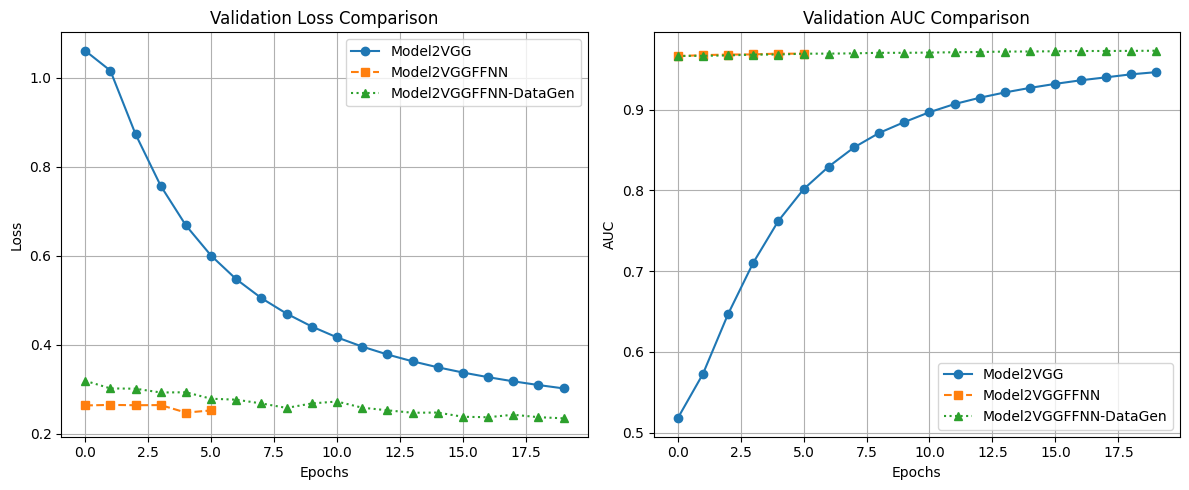

In [ ]:
# Function to plot loss, val_loss - for CNN model with Transfer Learning+FFNN+Data Augumentation
plot_history(vgg_histories, model_names)

# **Model Performance Comparison and Final Model Selection**

## Test Performance

In [ ]:
y_pred = vgg_ffnn_model.predict(X_test_rgb_orig)
classes = (y_pred > 0.4).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step


In [ ]:
report_dict = classification_report(y_test_rgb, classes,  output_dict=True)
print(pd.DataFrame(report_dict).T)

              precision    recall  f1-score     support
0              0.833333  0.773196  0.802139   97.000000
1              0.931889  0.952532  0.942097  316.000000
accuracy       0.910412  0.910412  0.910412    0.910412
macro avg      0.882611  0.862864  0.872118  413.000000
weighted avg   0.908741  0.910412  0.909226  413.000000


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


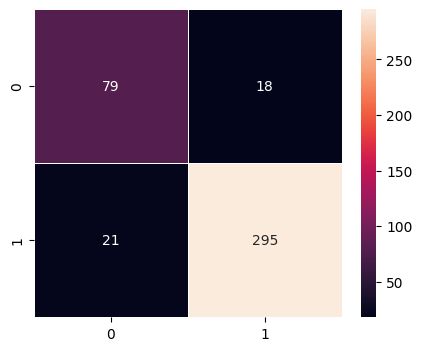

In [ ]:
vgg_ffnn_model_test = model_performance_classification(vgg_ffnn_model, X_test_rgb_orig,y_test_rgb)

## Observations on Test Data

**Validation (best model) Accuracy:** ~ 0.917  **Class 0 Recall:** ~0.906
**Test Accuracy:** 0.910 **Class 0 Recall:** 0.773

Drop in Class 0 recall (0.90 to 0.77) tells that final model is slightly less sensitive to minority class on unseen data.

**Model behavior:**

- **Class 0 Precision:** 0.83 is good **Recall:** 0.77 is moderate
That shows that model is more cautious on unseen data

- **Class 1 Precision:** 0.93 Recall: 0.95 both are very stable

On the test set, a drop in minority-class recall from ~0.90 to ~0.77, which is expected due to distribution shift and class imbalance. To address this, I adjusted the decision threshold to improve recall while maintaining acceptable precision, aligning model behavior with business priorities.

### **Comparing Transfer Learning against best CNN Model**

#### Head-to-Head Comparison: CNN (RGB) vs VGG16 (Final)

| Metric            | CNN (RGB) | VGG16 (Final) | Winner  |
|------------------|----------|--------------|---------|
| Accuracy         | 0.893    | 0.910        | VGG  |
| Macro F1         | 0.866    | 0.872        | VGG  |
| Macro Recall     | 0.912    | 0.863        | CNN  |
| Stability        | Medium   | High         | VGG  |
| Generalization   | Medium   | High         | VGG  |

The **custom CNN model** demonstrates strong sensitivity (recall), making it effective for detecting safety violations. However, the **transfer learning model** provides better overall balance and generalization, which is critical for scalable deployment in real-world environments.

**Final Recommendation** is to deploy: VGG16 + FFNN + Augmentation because:

* Best overall performance
* More stable
* Better generalization

The best CNN model was more aggressive in detecting violations, but VGG16 provided a better precision-recall balance, making it more suitable for production deployment.


# **Actionable Insights & Recommendations**

SafeGuard Corp's automated image analysis system aims to detect whether workers are wearing safety helmets. Key Objective of the model is to detect “Without Helmet” (Class 0) to improve safety enforcement, ensuring compliance and reducing the risk of head injuries.

* Missing a violation means potential injury/fatality
* False alarm means just operational inconvenience

**Final Model Recommendation**
Selected Model **VGG16 + FFNN + Data Augmentation**

* Best balance of recall and precision
* Strong generalization
* Stable real-world performance
* Recommended Threshold 0.35 - 0.40

- Improves detection of violations
- Maintains acceptable false positives
- Expected Production Performance Accuracy: ~91%
- No Helmet Recall: ~80–85% (after tuning)
- High confidence predictions (low ambiguity zone)

## **Actionable Recommendations**

**1. Optimize for Safety (Not Just Accuracy)**
- Prioritize recall for “Without Helmet”
- Use threshold tuning as control knob

**2. Deploy with Monitoring & Feedback Loop and Track**
- False negatives (missed violations)
- False positives
- Continuously retrain with new data

**3. Improve Dataset for Next Iteration and Focus on**
- more “Without Helmet” samples
- Edge cases like Poor lighting and Partial visibility

**4. Controlled Augmentation Strategy**
- Keep Spatial augmentations (flip, rotation, zoom)
- Limit Strong brightness/color shifts

**5. Introduce Confidence-Based Alerts**
- High confidence: auto alert
- Medium confidence: manual review
- Reduces false alarms in production

**6. Fine-Tuning for Future Gains**
- Unfreeze top VGG layers
- Use low learning rate

### **Strategic Takeaway**

The solution achieves strong performance using transfer learning and controlled augmentation, with threshold tuning enabling alignment with safety-critical business objectives. The system is production-ready with a clear path for continuous improvement.

Final Conclusion

- Model meets business objective (helmet compliance detection)
- Achieves high accuracy and strong recall
- Handles real-world variability
- Ready for deployment with monitoring